In [1]:
from os import path, mkdir, getcwd

import numpy as np
from sfeprapy.func.xlsx import xlsx_to_dict
from tqdm import tqdm

getcwd()

'C:\\Users\\Yan\\Documents\\GitHub\\EFSPRAPY\\test\\mcs1-case_study_1'

In [2]:
# inputs
fp_input = path.join(getcwd(), "case_study_1.xlsx")
dir_work = path.join(path.dirname(fp_input))
try:
    mkdir(dir_work)
except:
    pass

assert path.exists(fp_input), f'file does not exist {fp_input}'

In [3]:
mcs_input = xlsx_to_dict(fp_input)
x_target = None
y_target = None
x_br187_084 = list()
y_br187_084 = list()
x_office = list()
y_office = list()
x_office_sprinklered = list()
y_office_sprinklered = list()
for k, v in tqdm(mcs_input.items()):
    fp_output = path.join(
        path.dirname(fp_input),
        f"{path.splitext(path.basename(fp_input))[0]}.out",
        f"{k}.csv",
    )
    assert path.exists(fp_output), f'file does not exist {fp_output}'
    N = int(v["n_simulations"])

    mcs_output = np.genfromtxt(fp_output, delimiter=",", skip_header=1)
    t_ig_ftp = mcs_output[:, 1]
    P_ig = sum(np.logical_and(t_ig_ftp > 0, t_ig_ftp < np.inf)) / float(N)

    separation_distance = float(v["receiver_separation"])

    if "br187_084_" in k:
        x_br187_084.append(float(v["receiver_separation"]))
        y_br187_084.append(P_ig)
    elif "br187" in k:
        x_target = float(v["receiver_separation"])
        y_target = P_ig
    elif "sprinklered" in k:
        x_office_sprinklered.append(float(v["receiver_separation"]))
        y_office_sprinklered.append(P_ig)
    elif "office" in k:
        x_office.append(float(v["receiver_separation"]))
        y_office.append(P_ig)

100%|██████████| 61/61 [00:00<00:00, 308.41it/s]


In [4]:
x_office_required = np.interp(y_target, list(
    reversed(y_office)), list(reversed(x_office)))
x_office_sprinklered_required = np.interp(
    y_target, list(reversed(y_office_sprinklered)), list(
        reversed(x_office_sprinklered))
)

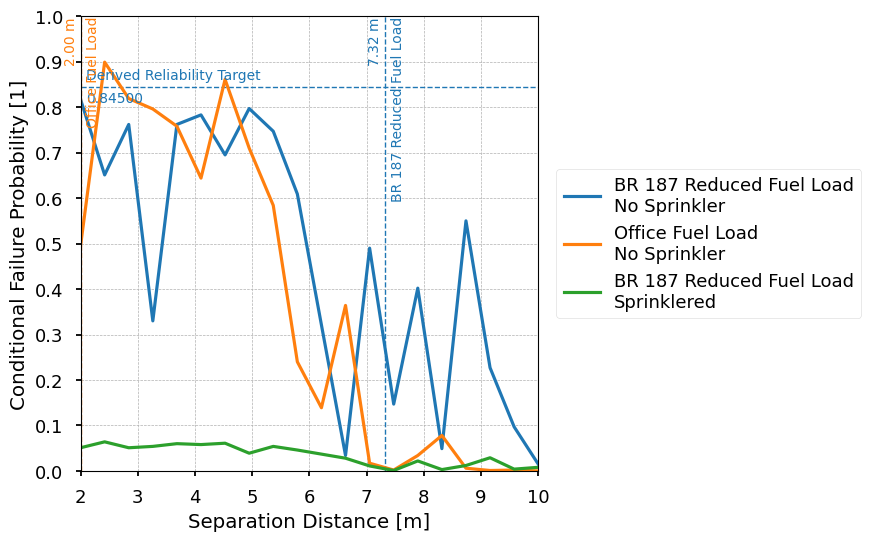

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-talk')

fig, ax = plt.subplots(figsize=(5.90551, 5.90551), dpi=100)

ax.set_xlabel("Separation Distance [m]")
ax.set_ylabel("Conditional Failure Probability [1]")
ax.set_xlim(2, 10)
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.grid(which="both", ls="--", lw=0.5)

# br 187 084 base case
l1 = ax.plot(x_br187_084, y_br187_084, label='BR 187 Reduced Fuel Load\nNo Sprinkler')
ax.legend(bbox_to_anchor=(1.02, 0.5), loc='center left').set_visible(True)
fig.savefig(
    path.join(path.dirname(fp_input), "mcs1-case_study_1_1.png"),
    dpi=600, bbox_inches="tight", pad_inches=0.02, transparent=True,
)

ax.axvline(x_target, ls="--", color=l1[0].get_color(), lw=1)
ax.text(x_target + 0.1, 1, "BR 187 Reduced Fuel Load", color=l1[0].get_color(), ha="left", va="top", rotation=90, )
ax.text(x_target - 0.05, 1, f"{x_target:.2f} m", color=l1[0].get_color(), ha="right", va="top", rotation=90, )
ax.legend(bbox_to_anchor=(1.02, 0.5), loc='center left').set_visible(True)
fig.savefig(
    path.join(path.dirname(fp_input), "mcs1-case_study_1_2.png"),
    dpi=600, bbox_inches="tight", pad_inches=0.02, transparent=True,
)
ax.axhline(y_target, ls="--", color=l1[0].get_color(), lw=1)
ax.text(2.1, y_target + 0.01, "Derived Reliability Target", color=l1[0].get_color(), ha="left", va="bottom", )
ax.text(2.1, y_target - 0.01, f"{y_target:.5f}", color=l1[0].get_color(), ha="left", va="top", )
ax.legend(bbox_to_anchor=(1.02, 0.5), loc='center left').set_visible(True)
fig.savefig(
    path.join(path.dirname(fp_input), "mcs1-case_study_1_3.png"),
    dpi=600, bbox_inches="tight", pad_inches=0.02, transparent=True,
)

# office fuel load
l2 = ax.plot(x_office, y_office, label='Office Fuel Load\nNo Sprinkler')
ax.legend(bbox_to_anchor=(1.02, 0.5), loc='center left').set_visible(True)
fig.savefig(
    path.join(path.dirname(fp_input), "mcs1-case_study_1_4.png"),
    dpi=600, bbox_inches="tight", pad_inches=0.02, transparent=True,
)
ax.axvline(x_office_required, ls="--", color=l2[0].get_color(), lw=1)
ax.text(x_office_required + 0.1, 1, "Office Fuel Load", color=l2[0].get_color(), ha="left", va="top", rotation=90, )
ax.text(x_office_required - 0.05, 1, f"{x_office_required:.2f} m", color=l2[0].get_color(), ha="right", va="top",
        rotation=90, )
ax.legend(bbox_to_anchor=(1.02, 0.5), loc='center left').set_visible(True)
fig.savefig(
    path.join(path.dirname(fp_input), "mcs1-case_study_1_5.png"),
    dpi=600, bbox_inches="tight", pad_inches=0.02, transparent=True,
)

l3 = ax.plot(x_office_sprinklered, y_office_sprinklered, label='BR 187 Reduced Fuel Load\nSprinklered')
ax.legend(bbox_to_anchor=(1.02, 0.5), loc='center left').set_visible(True)
fig.savefig(
    path.join(path.dirname(fp_input), "mcs1-case_study_1_6.png"),
    dpi=600, bbox_inches="tight", pad_inches=0.02, transparent=True,
)